# AllLife Bank Personal Loan Campaign

## Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

## Objective

- To predict whether a liability customer will buy personal loans.
- Which variables are most significant.
- Which segment of customers should be targeted more.

## Data Dictionary

- ID: Customer ID
- Age: Customer’s age in completed years
- Experience: #years of professional experience
- Income: Annual income of the customer (in thousand dollars)
- ZIP Code: Home Address ZIP code.
- Family: the Family size of the customer
- CCAvg: Average spending on credit cards per month (in thousand dollars)
- Education: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
- Mortgage: Value of house mortgage if any. (in thousand dollars)
- Personal_Loan: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
- Securities_Account: Does the customer have securities account with the bank? (0: No, 1: Yes)
- CD_Account: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
- Online: Do customers use internet banking facilities? (0: No, 1: Yes)
- CreditCard: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

In [1]:
#let us import the libraries

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_theme()

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (f1_score, accuracy_score , recall_score, precision_score, 
                             confusion_matrix, roc_auc_score, plot_confusion_matrix, precision_recall_curve,roc_curve,
                             make_scorer)

In [2]:
loan_data = pd.read_csv("Loan_Modelling (1).csv")
loan_data.shape

(5000, 14)

In [3]:
data = loan_data.copy()

In [4]:
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [5]:
data.columns = data.columns.str.lower() # converting the column names in lower case

In [6]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   experience          5000 non-null   int64  
 3   income              5000 non-null   int64  
 4   zipcode             5000 non-null   int64  
 5   family              5000 non-null   int64  
 6   ccavg               5000 non-null   float64
 7   education           5000 non-null   int64  
 8   mortgage            5000 non-null   int64  
 9   personal_loan       5000 non-null   int64  
 10  securities_account  5000 non-null   int64  
 11  cd_account          5000 non-null   int64  
 12  online              5000 non-null   int64  
 13  creditcard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


#### There are no nun values in the dataset

In [7]:
# let us convert the categorical features to category from numeric features

cat_feature =["education","personal_loan", "securities_account","online", "creditcard"]

data[cat_feature] = data[cat_feature].astype("category")

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
zipcode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
ccavg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
cd_account,5000.0,0.060400,0.238250,0.0,0.00,0.0,0.00,1.0


- ID: The ID attribute does not add any information to our analysis as all the values are unique. There is no association between a person's customer ID and loan, also it does not provide any general conclusion for future potential loan customers. We can neglect this information for our model prediction.

- A negative experience of -3 seems to be a data entry error. The average working experience of the customers is ~20 years, we have some highly experienced working professions in the data.

- ZIPCode: ZIPCode seems to have many unique values, we will see if some insights can be extracted from it.

- CCAvg: Some customers have average spending of 0 dollars a month. There's a huge difference in the 75th percentile and maximum value of the average spendings indicating that there might be outliers presen

In [9]:
data.describe(include="category").T

,count,unique,top,freq
education,5000,3,1,2096
personal_loan,5000,2,0,4520
securities_account,5000,2,0,4478
online,5000,2,1,2984
creditcard,5000,2,0,3530


In [10]:
data.drop("id", axis =1 , inplace = True)  #since ID does not add any value

In [11]:
for i in cat_feature:
    print (data[i].value_counts())
    print ("*********"*10)

1    2096
3    1501
2    1403
Name: education, dtype: int64
******************************************************************************************
0    4520
1     480
Name: personal_loan, dtype: int64
******************************************************************************************
0    4478
1     522
Name: securities_account, dtype: int64
******************************************************************************************
1    2984
0    2016
Name: online, dtype: int64
******************************************************************************************
0    3530
1    1470
Name: creditcard, dtype: int64
******************************************************************************************


- Most of the people are undergrad
- most of the customers do not use the online banking facility

#  Data visusalization and EDA

## Univariate analysis

In [12]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

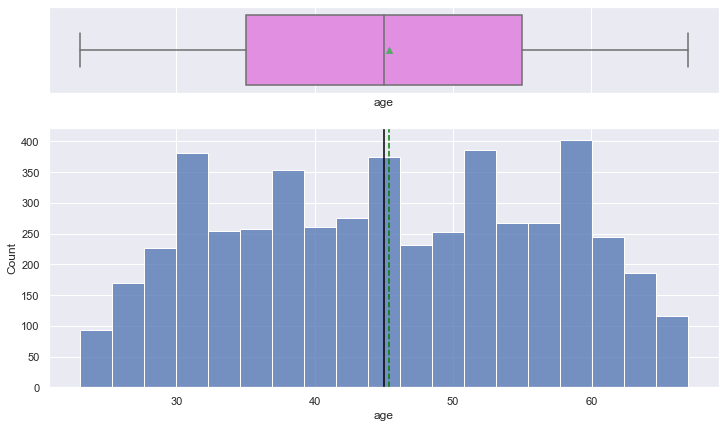

In [13]:
histogram_boxplot(data,"age")

The mean and median age of customers is almost equal to ~45 year

In [14]:
# there are a few negative values in experience
data[data['experience']<0]["experience"].unique()

array([-1, -2, -3], dtype=int64)

In [15]:
data['experience'].replace(-1,1, inplace = True)
data['experience'].replace(-2,2, inplace = True)
data['experience'].replace(-3,3, inplace = True)

In [16]:
data['experience'].describe().T

count    5000.000000
mean       20.134600
std        11.415189
min         0.000000
25%        10.000000
50%        20.000000
75%        30.000000
max        43.000000
Name: experience, dtype: float64

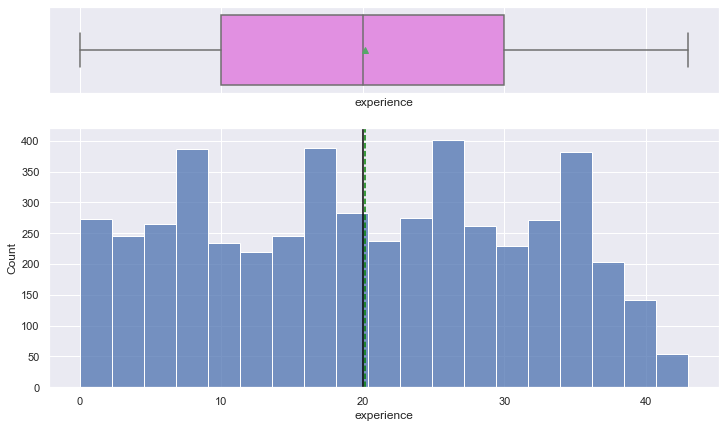

In [17]:
histogram_boxplot(data, "experience")

- The distribution seems to symmetrical
- medain and mean experience is around 20 years
- some customers have experience more than 40 years

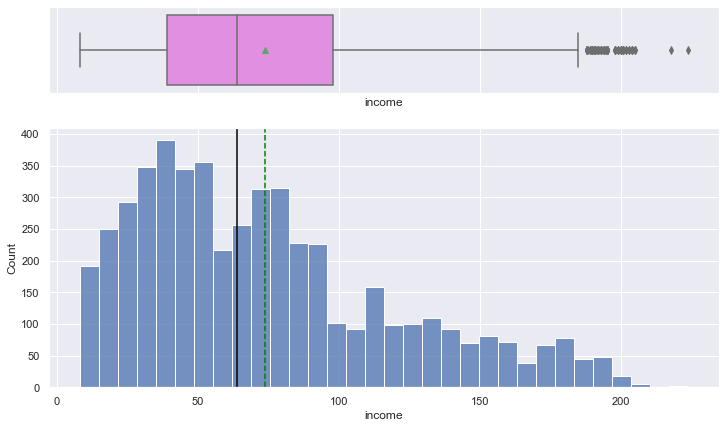

In [18]:
histogram_boxplot(data, "income")

- the median income of the customers is 64k dollars, ie 50% is less then 64k dollars
- the distribution is right skewed
- some fraction of the customer has income more then 200k

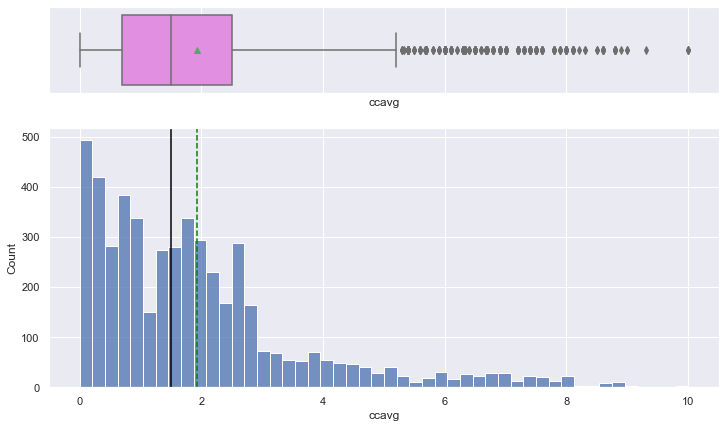

In [19]:
histogram_boxplot(data,"ccavg")

 - The distribution is rightly skewed and has a lot of outliers
 - 50 % of customers have ccavg less tahn 1.5

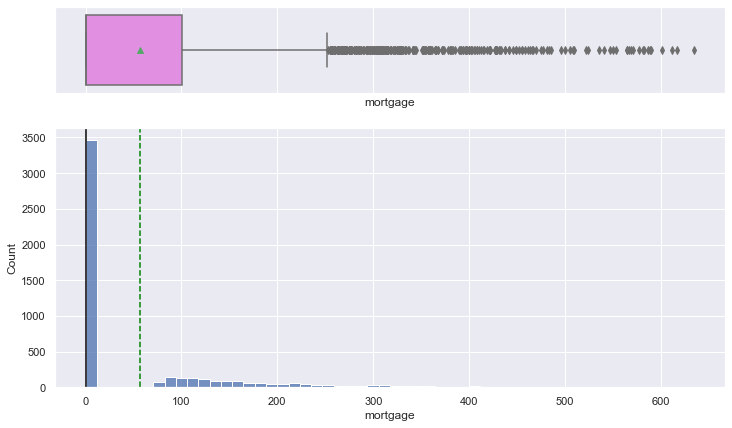

In [20]:
histogram_boxplot(data, "mortgage")

- some customer have mortgage on higher side and hence potentially personal loan candidates

### Let us create labeled barplot

In [21]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

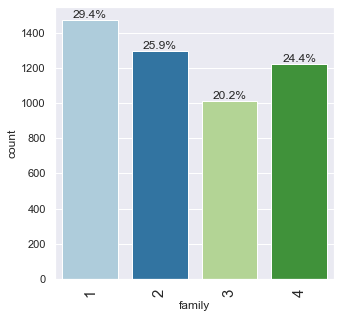

In [22]:
labeled_barplot(data,"family", perc = True)

#Most of the customers are single/live alone (~30%).
#Second most are the ones with one dependent on them (25.9%).

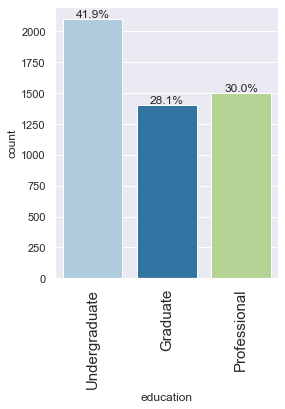

In [23]:
#for a better understanding of education we would be replacing with degree

data["education"].replace(1, "Undergraduate", inplace=True)
data["education"].replace(2, "Graduate", inplace=True)
data["education"].replace(3, "Professional", inplace=True)

labeled_barplot(data, "education", perc = True) 

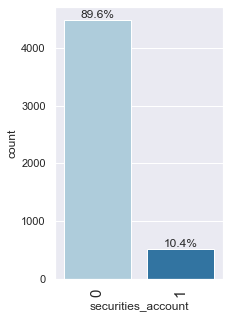

In [24]:
labeled_barplot(data, "securities_account", perc = True)

- apprximately 90% people do not have a securities account with us
- 41.9% of people are undergrads

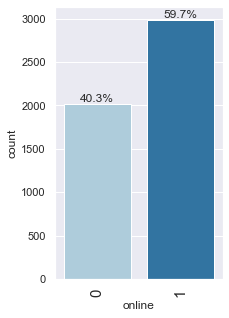

In [25]:
labeled_barplot(data, "online",perc = True)

Approximately 60% of the customers use internet banking facilities.

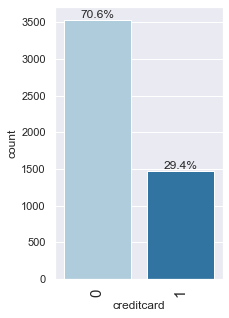

In [26]:
labeled_barplot(data, "creditcard", perc = True)

70% people do not have credit card issues with other banks

###  Observations on zip code

In [27]:
data['zipcode'].nunique()

467

- There are 467 unique values in the zip code.
- In the US, The first digit of a PIN indicates the zone or a region, the second indicates the sub-zone, and the third, combined with the first two, indicates the sorting district within that zone. The final three digits are assigned to individual post offices within the sorting district
- Let's try to group them based on the first 2 digits to reduce the number of unique values in the ZIPCode column.

In [28]:
data['zipcode'] = data['zipcode'].astype(str)

data ["zipcode"] = data['zipcode'].str[0:2]

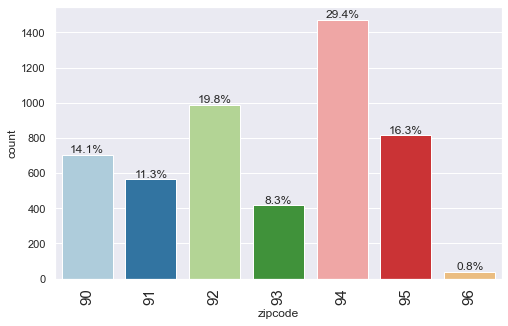

In [29]:
labeled_barplot(data, "zipcode", perc = True)

- All the customers are from region 9 and Interestinglly 30% of the customers are from zip code 94

## Bivariate analysis

<AxesSubplot:>

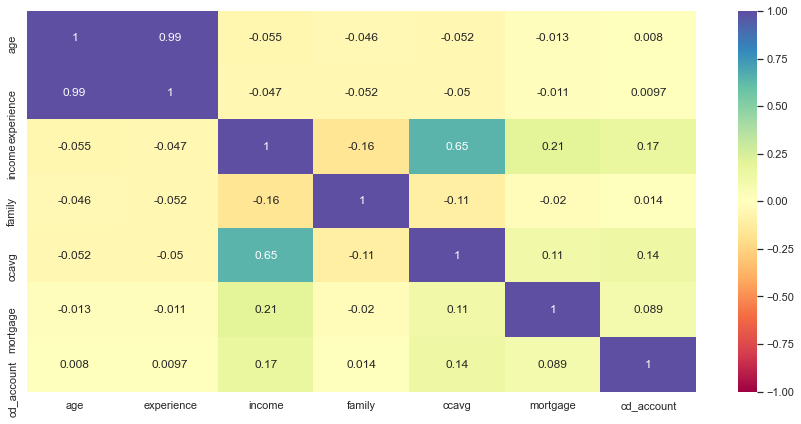

In [30]:
plt.figure(figsize =(15,7))
sns.heatmap(data.corr(), vmax=+1, vmin = -1, annot= True, cmap = "Spectral")

- Age and Experience have a perfect correlation hence one of these variables can be dropped while model building as they will provide the same information to the model.
- Income and CCAvg have a moderate correlation which makes sense as the Income increases the spendings might also increase.
- Family has a negative correlation with Income, which is quite surprising as family size increases the income of the family decreases. But this correlation is not too strong to conclude.

In [31]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

personal_loan     0    1   All
education                     
All            4520  480  5000
Professional   1296  205  1501
Graduate       1221  182  1403
Undergraduate  2003   93  2096
------------------------------------------------------------------------------------------------------------------------


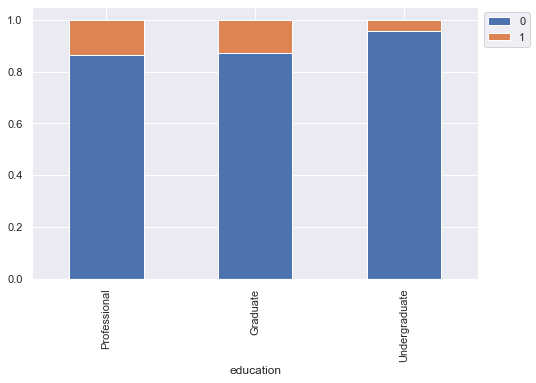

In [32]:
stacked_barplot(data, "education", "personal_loan")

 - approx 15% of professional study , takes a personal loan
 - undergraduates do not require personal loan

personal_loan     0    1   All
family                        
All            4520  480  5000
4              1088  134  1222
3               877  133  1010
1              1365  107  1472
2              1190  106  1296
------------------------------------------------------------------------------------------------------------------------


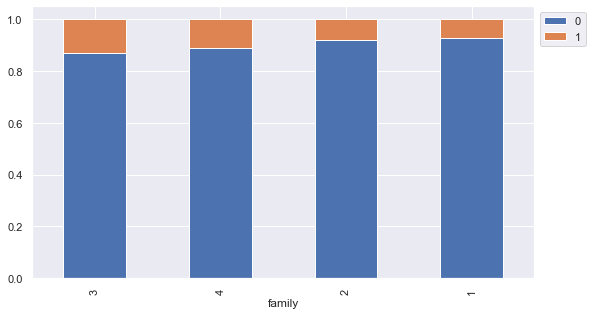

In [33]:
stacked_barplot(data, "family", "personal_loan")

- As the family size increases the requirement of a Personal Loan also increases.
- Customers who have a family size of more than 2 are more likely to take a Personal Loan.

personal_loan          0    1   All
securities_account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


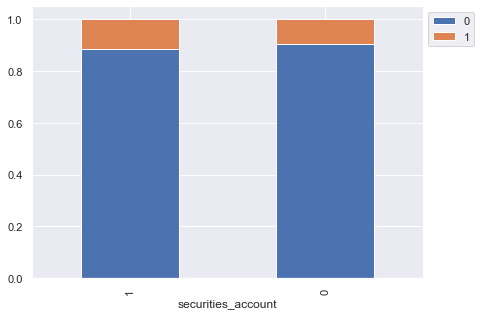

In [34]:
stacked_barplot(data, "securities_account", "personal_loan")

personal_loan     0    1   All
cd_account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


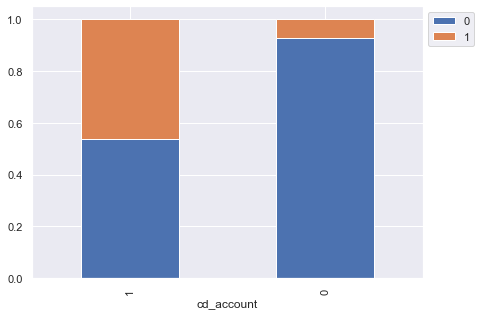

In [35]:
stacked_barplot(data, "cd_account", "personal_loan")

- ~50% of the customers who have a certificate of deposit with the bank (CD_Account) are the ones that have the requirement of a Personal Loan.
- This can be one of the significant predictors of Personal Loan as it provides good separation between two classes.

personal_loan     0    1   All
online                        
All            4520  480  5000
1              2693  291  2984
0              1827  189  2016
------------------------------------------------------------------------------------------------------------------------


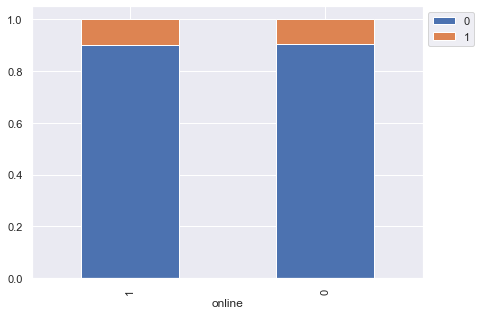

In [36]:
stacked_barplot(data, "online", "personal_loan")

personal_loan     0    1   All
creditcard                    
All            4520  480  5000
0              3193  337  3530
1              1327  143  1470
------------------------------------------------------------------------------------------------------------------------


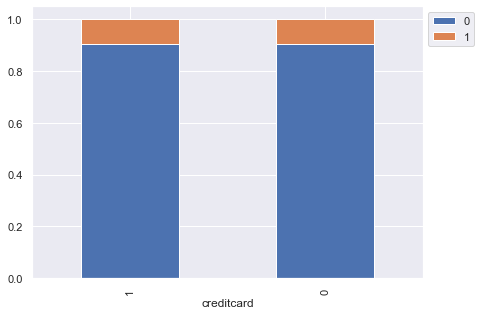

In [37]:
stacked_barplot(data, "creditcard", "personal_loan")

personal_loan     0    1   All
zipcode                       
All            4520  480  5000
94             1334  138  1472
92              894   94   988
95              735   80   815
90              636   67   703
91              510   55   565
93              374   43   417
96               37    3    40
------------------------------------------------------------------------------------------------------------------------


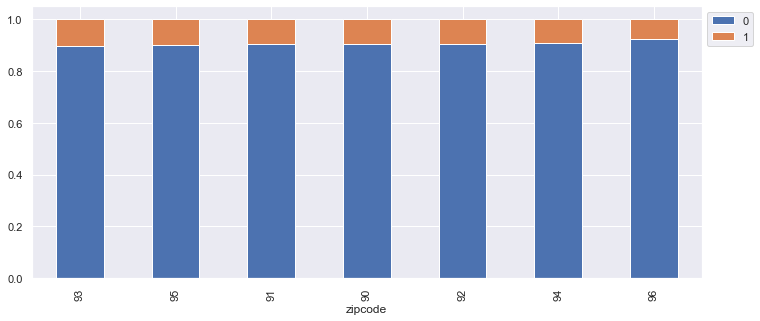

In [38]:
stacked_barplot(data, "zipcode", "personal_loan")

- All the subregions show fairly equal requirement of the loan

In [39]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

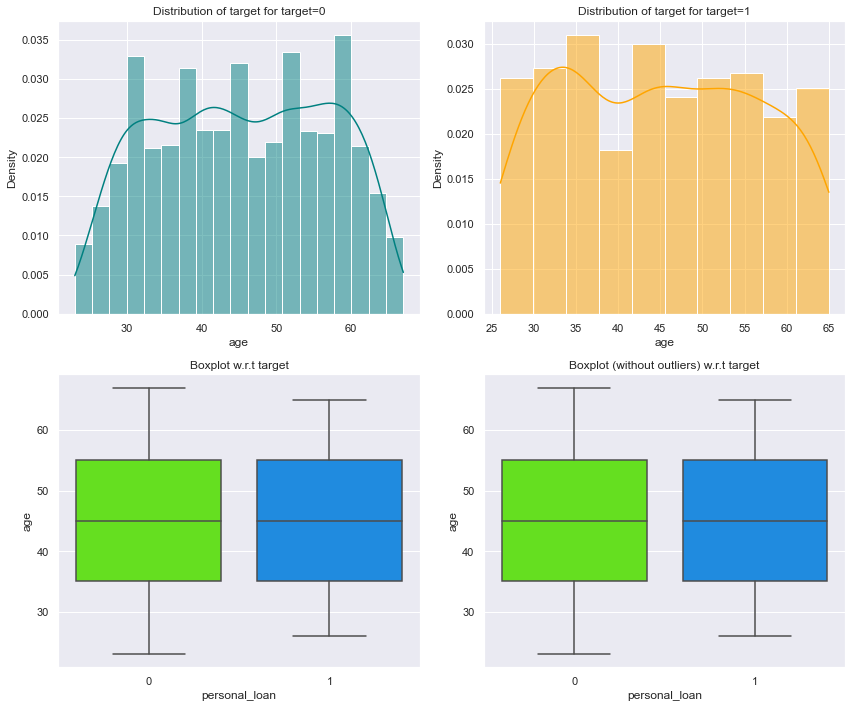

In [40]:
distribution_plot_wrt_target(data,"age", "personal_loan")

- The customers who have the requirement of a Personal Loan have a wider range than the ones who do not require a Personal Loan.

### Let's find the percentage of outliers, in each column of the data, using IQR

In [41]:
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)

IQR = q3-q1

lower = (q1- 1.5*IQR)
upper = (q3 +1.5*IQR)

In [42]:
((data.select_dtypes(include=["float64","int64"])< lower) | (data.select_dtypes(include=["float64","int64"])> upper)
).sum()/len(data)*100

age           0.00
experience    0.00
income        1.92
family        0.00
ccavg         6.48
mortgage      5.82
cd_account    6.04
dtype: float64

We would not want to work on the outliers mentioned the above outputs, as they look real life scenarios, like income can be high, simmillarly mortgage, cd_account and ccavg

### Let us find missing values and a bit of data description

In [44]:
data.isnull().sum() # no missing values

age                   0
experience            0
income                0
zipcode               0
family                0
ccavg                 0
education             0
mortgage              0
personal_loan         0
securities_account    0
cd_account            0
online                0
creditcard            0
dtype: int64

In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   age                 5000 non-null   int64   
 1   experience          5000 non-null   int64   
 2   income              5000 non-null   int64   
 3   zipcode             5000 non-null   object  
 4   family              5000 non-null   int64   
 5   ccavg               5000 non-null   float64 
 6   education           5000 non-null   category
 7   mortgage            5000 non-null   int64   
 8   personal_loan       5000 non-null   category
 9   securities_account  5000 non-null   category
 10  cd_account          5000 non-null   int64   
 11  online              5000 non-null   category
 12  creditcard          5000 non-null   category
dtypes: category(5), float64(1), int64(6), object(1)
memory usage: 337.7+ KB


In [46]:
data["zipcode"] = data['zipcode'].astype("category")

In [48]:
x = data.drop(['personal_loan', "experience"], axis =1)
y = data['personal_loan']

x = pd.get_dummies(x, drop_first= True) # changing in dummy variable

In [50]:
x.shape

(5000, 17)

In [51]:
x_train, x_test , y_train, y_test = train_test_split(x,y, test_size= 0.3, random_state=1)

In [58]:
print ("Shape of x_train is",x_train.shape)
print ("Shape of x_test is",x_test.shape)

print ("value counts:\n", y_train.value_counts(normalize=True))
print ("value counts:\n",y_test.value_counts(normalize=True))

Shape of x_train is (3500, 17)
Shape of x_test is (1500, 17)
value counts:
 0    0.905429
1    0.094571
Name: personal_loan, dtype: float64
value counts:
 0    0.900667
1    0.099333
Name: personal_loan, dtype: float64


## Model building and evaluation 

#### Bank would want Recall to be maximized, greater the Recall higher the chances of minimizing false negatives. Hence, the focus should be on increasing Recall or minimizing the false negatives.

2 functions to be built:
- The model_performance_classification_sklearn_with_threshold function will be used to check the model performance of models.
- The confusion_matrix_sklearn_with_threshold function will be used to plot confusion matrix.


In [72]:
def model_performance_classification_sklearn_with_threshold(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics, based on the threshold specified, to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # predicting using the independent variables
    pred_prob = model.predict_proba(predictors)[:, 1]
    pred_thres = pred_prob > threshold
    pred = np.round(pred_thres)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [73]:
def confusion_matrix_sklearn_with_threshold(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix, based on the threshold specified, with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    pred_prob = model.predict_proba(predictors)[:, 1]
    pred_thres = pred_prob > threshold
    y_pred = np.round(pred_thres)

    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Logistic regression

In [74]:
lg = LogisticRegression(solver ="newton-cg", random_state=1)

In [75]:
model = lg.fit(x_train, y_train)

In [76]:
log_odds = lg.coef_[0]
pd.options.display.float_format ="{:.5f}".format
pd.DataFrame(log_odds, x_train.columns, columns= ["coeff"]).T

,age,income,family,ccavg,mortgage,cd_account,zipcode_91,zipcode_92,zipcode_93,zipcode_94,zipcode_95,zipcode_96,education_Graduate,education_Professional,securities_account_1,online_1,creditcard_1
coeff,0.00487,0.05467,0.63135,0.18623,0.00089,3.11939,-0.11836,0.23322,0.21395,0.02094,-0.01114,-0.31270,3.32758,3.42572,-0.78992,-0.53051,-0.84321


In [85]:
odds = np.exp(lg.coef_[0])
perc_change_odds = (np.exp(lg.coef_[0])-1)*100

pd.DataFrame({"odds":odds,"change_odd%":perc_change_odds}, index=x_train.columns).T

,age,income,family,ccavg,mortgage,cd_account,zipcode_91,zipcode_92,zipcode_93,zipcode_94,zipcode_95,zipcode_96,education_Graduate,education_Professional,securities_account_1,online_1,creditcard_1
odds,1.00489,1.05619,1.88015,1.20470,1.00089,22.63257,0.88838,1.26266,1.23856,1.02116,0.98892,0.73147,27.87080,30.74464,0.45388,0.58831,0.43033
change_odd%,0.48860,5.61936,88.01470,20.47009,0.08916,2163.25686,-11.16248,26.26637,23.85647,2.11572,-1.10776,-26.85319,2687.08004,2974.46381,-54.61206,-41.16924,-56.96744


Coefficient interpratation
- Coefficients of Age, Income, Family, CCAvg, CD_Account, and Education, and some levels of ZIPCode are positive an increase in these will lead to an increase in chances of taking a personal loan.

#### Model performance on trainning set

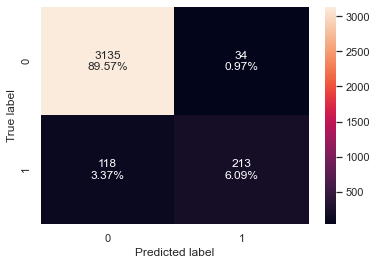

In [77]:
confusion_matrix_sklearn_with_threshold(lg,x_train, y_train)

In [80]:
log_reg_model_train_perf = model_performance_classification_sklearn_with_threshold(lg,x_train, y_train)
log_reg_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.95657,0.64350,0.86235,0.73702


In [119]:
log_reg_model_test_perf = model_performance_classification_sklearn_with_threshold(lg,x_test, y_test)
log_reg_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.95733,0.63087,0.91262,0.74603


#### ROC- AUC on trainning set

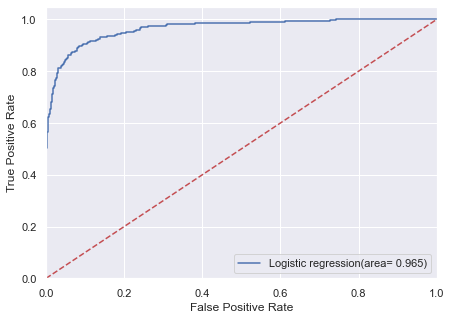

In [98]:
logit_roc_auc_train = roc_auc_score(y_train, lg.predict_proba(x_train)[:,1])
fpr, tpr, threshold = roc_curve(y_train, lg.predict_proba(x_train)[:,1])

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label ="Logistic regression(area= %0.3f)"%logit_roc_auc_train)
plt.xlabel("False Positive Rate")
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

Logistic Regression model is giving a good performance on training set.
ROC-AUC score of 0.96 on training is quite good.

In [102]:
optimal_idx =np.argmax(tpr-fpr)
optimal_threshold_auc_roc = threshold[optimal_idx]
optimal_threshold_auc_roc

0.11898817409479859

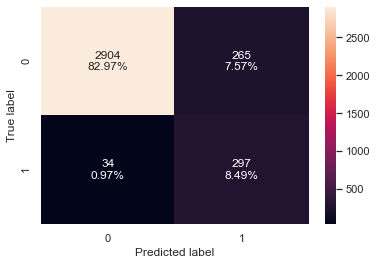

In [104]:
confusion_matrix_sklearn_with_threshold(
    lg, x_train, y_train, threshold=0.118988
)

In [106]:
log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_sklearn_with_threshold(
    lg, x_train, y_train, threshold=optimal_threshold_auc_roc
)
print("Training performance:")
log_reg_model_train_perf_threshold_auc_roc

Training performance:


,Accuracy,Recall,Precision,F1
0,0.91429,0.89426,0.52763,0.66368


In [121]:
log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_sklearn_with_threshold(
    lg, x_test, y_test, threshold=0.118988
)
print("Testing performance:")
log_reg_model_test_perf_threshold_auc_roc

Testing performance:


,Accuracy,Recall,Precision,F1
0,0.91133,0.85906,0.53333,0.65810


#### The recall has significantly increased compared to the previous model, if you keeo decreasing the threshold, you would see increase in recall

In [108]:
log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_sklearn_with_threshold(
    lg, x_test, y_test, threshold=
)
print("Test performance:")
log_reg_model_test_perf_threshold_auc_roc

Test performance:


,Accuracy,Recall,Precision,F1
0,0.91133,0.85906,0.53333,0.65810


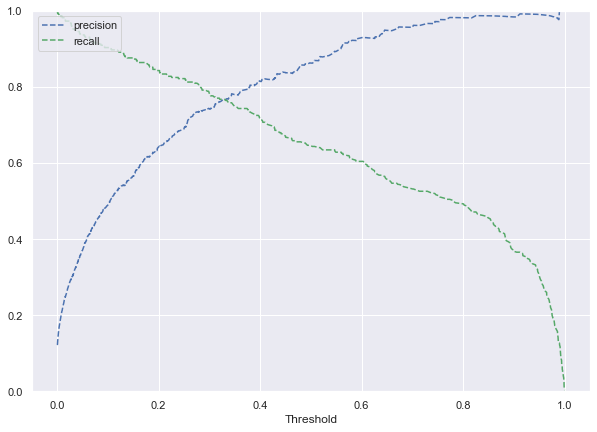

In [113]:
y_scores = lg.predict_proba(x_train)[:, 1]
prec, rec, tre = precision_recall_curve(y_train, y_scores,)
def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])

plt.figure(figsize=(10, 7))  
plot_prec_recall_vs_tresh(prec,rec, tre)

At threshold around 0.27 we get a higher recall and a good precision.

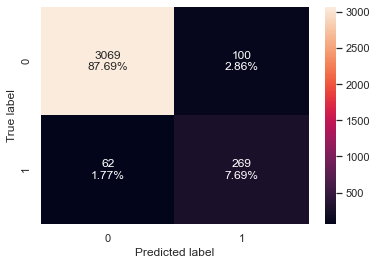

In [115]:
confusion_matrix_sklearn_with_threshold(
    lg, x_train, y_train, threshold=0.27
)

In [117]:
log_reg_model_train_perf_threshold_curve = model_performance_classification_sklearn_with_threshold(
    lg, x_train, y_train, threshold=0.27
)
print("Training performance:")
log_reg_model_train_perf_threshold_curve

Training performance:


,Accuracy,Recall,Precision,F1
0,0.95371,0.81269,0.72900,0.76857


In [118]:
log_reg_model_test_perf_threshold_curve = model_performance_classification_sklearn_with_threshold(
    lg, x_test, y_test, threshold=0.27
)
print("test performance:")
log_reg_model_test_perf_threshold_curve

test performance:


,Accuracy,Recall,Precision,F1
0,0.94933,0.73826,0.74830,0.74324


In [123]:
models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_model_train_perf_threshold_auc_roc.T,
        log_reg_model_train_perf_threshold_curve.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression sklearn",
    "Logistic Regression-0.11 Threshold",
    "Logistic Regression-0.27 Threshold",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression sklearn,Logistic Regression-0.11 Threshold,Logistic Regression-0.27 Threshold
Accuracy,0.95657,0.91429,0.95371
Recall,0.64350,0.89426,0.81269
Precision,0.86235,0.52763,0.72900
F1,0.73702,0.66368,0.76857


In [124]:
models_test_comp_df = pd.concat(
    [
        log_reg_model_test_perf.T,
        log_reg_model_test_perf_threshold_auc_roc.T,
        log_reg_model_test_perf_threshold_curve.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression sklearn",
    "Logistic Regression-0.11 Threshold",
    "Logistic Regression-0.27 Threshold",
]

print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Logistic Regression sklearn,Logistic Regression-0.11 Threshold,Logistic Regression-0.27 Threshold
Accuracy,0.95733,0.91133,0.94933
Recall,0.63087,0.85906,0.73826
Precision,0.91262,0.53333,0.74830
F1,0.74603,0.65810,0.74324


We have been able to build a predictive model that can be used by the bank to find the potential customers who will be willing to take a personal loan with recall of 0.85 on the training set and formulate marketing policies accordingly.

- Using the model with 0.11 threshold the model will give a high recall but low precision score - This model will help the bank identify potential customers effectively but the cost of resources will be high.
- Using the model with 0.27 threshold the model will give a balance recall and precision score - This model will help the bank to maintain a balance in identifying potential customer and the cost of resources.